<a href="https://colab.research.google.com/github/calvinpan1/ds3001_demandestproject/blob/main/Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Data Analysis


In [1]:
# Load dataset
import pandas as pd

url = "https://raw.githubusercontent.com/ds4e/undergrad_ml_assignments/main/demand_est_project/air_fryers_clean_brand_year.csv"

airfryers = pd.read_csv(url)

# Save into current working directory
airfryers.to_csv("air_fryers_clean_brand_year.csv", index=False)

# Check
airfryers.head(10)

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364
5,air_fryers,2019,instant_pot,238,13,78.019945,4.364286,0.542017,0.0,0.550420,0.000000,0.000000,15076,0.015787,-4.148589
6,air_fryers,2019,ninja,2904,18,112.158374,4.778650,0.994490,0.0,0.000000,0.000000,0.000000,15076,0.192624,-1.647015
7,air_fryers,2019,nuwave,484,15,151.099937,4.321901,0.993802,0.0,0.561983,0.111570,0.000000,15076,0.032104,-3.438774
8,air_fryers,2019,oster,506,5,191.943688,4.380830,1.000000,0.0,0.772727,0.000000,0.000000,15076,0.033563,-3.394323
9,air_fryers,2019,ultrean,755,4,80.624675,4.618013,1.000000,0.0,0.835762,0.000000,0.000000,15076,0.050080,-2.994142


1.

In [2]:
# Verify the number of brands
print("Number of brands:", airfryers["brand"].nunique())

# Verify years
print("Years:", sorted(airfryers["year"].unique()))

Number of brands: 10
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


2.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

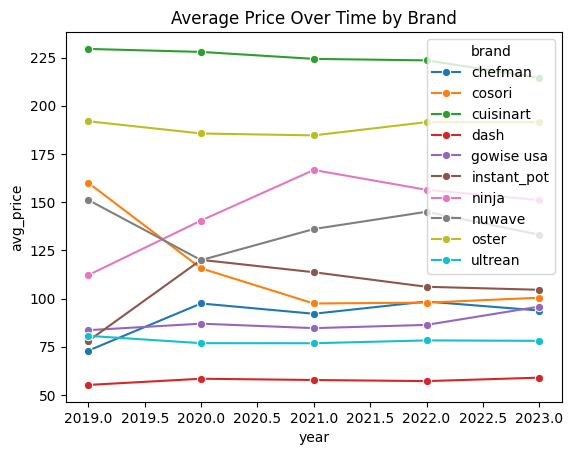

In [4]:
# Average price over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="avg_price", hue="brand", marker="o")
plt.title("Average Price Over Time by Brand")
plt.show()

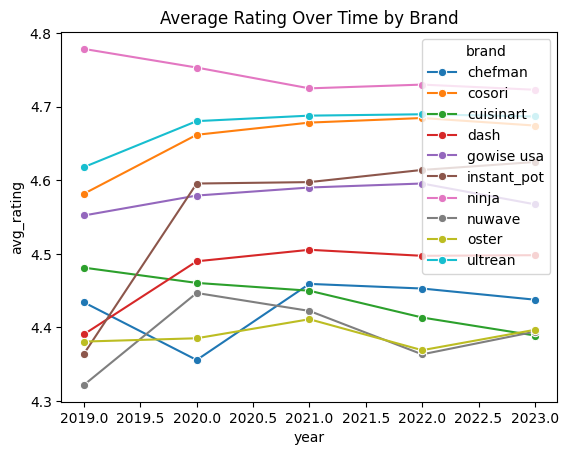

In [5]:
# Average rating over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="avg_rating", hue="brand", marker="o")
plt.title("Average Rating Over Time by Brand")
plt.show()

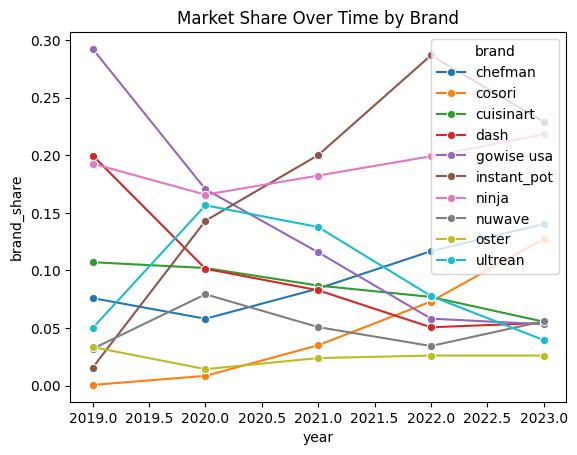

In [6]:
# Brand market share over time
plt.figure()
sns.lineplot(data=airfryers, x="year", y="brand_share", hue="brand", marker="o")
plt.title("Market Share Over Time by Brand")
plt.show()

3.

In [7]:
# Average feature shares
features = [
    "compact_share", "dual_basket_share", "oven_style_share",
    "rotisserie_share", "window_share"
]

airfryers[features].mean().sort_values(ascending=False)

,0
compact_share,0.980081
oven_style_share,0.562647
rotisserie_share,0.070762
window_share,0.036741
dual_basket_share,0.002260


The most common feature is compact design with an average share of about 98%. Oven-style models are also common with a share of about 56%.

There are several features that are rare. Specifically, rotisserie appears in only about 7% of products while window features are even less common at about 4%. The rarest feature is dual-basket design with a share of about 0.2%, indicating it is almost nonexistent in this market.

In [8]:
# By brand
airfryers.groupby("brand")[features].mean()

,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
brand,,,,,
chefman,0.961595,0.013462,0.596962,0.370490,0.363081
cosori,0.996784,0.000000,0.029952,0.024076,0.000000
cuisinart,0.995902,0.000000,0.913059,0.000000,0.000000
dash,0.999481,0.000000,0.890098,0.000000,0.000000
gowise usa,0.999877,0.000000,0.183790,0.183569,0.001320
instant_pot,0.859655,0.000030,0.674784,0.102362,0.003012
ninja,0.992084,0.002488,0.100477,0.000000,0.000000
nuwave,0.995431,0.006622,0.542646,0.027123,0.000000
oster,1.000000,0.000000,0.864518,0.000000,0.000000


There is evidence that some brands specialize in different product features. For example, Chefman offers a wider range of features with relatively high shares of rotisserie (about 37%) and window (about 36%) models. This suggests a focus on more feature heavy or premium designs. Gowise USA also shows some specialization in rotisserie models (about 18%), which is uncommon among other brands.

Other brands like Cuisinart, Dash, Oster, and Ultrean specialize in oven-style air fryers with very high oven-style shares (80% and above), indicating a focus on that specific product type.

Brands such as Cosori and Ninja are more concentrated in compact designs with very low shares of additional features. This suggests a more standardized product lineup.

4.

The market appears to be segmented by price but relatively stable over time. Cuisinart is consistently the most expensive brand with Ninja and Oster also positioned in the higher price range. Brands such as Dash, Ultrean, and Gowise USA occupy the low price segment. In terms of market share, Instant Pot grows to become the dominant brand, holding the largest share in later years. Additionally, Ninja maintains a relatively strong position. The majority of other brands have smaller or declining shares. Overall, the market looks fairly stable. Specifically, prices and ratings change only slightly over time. While there are some gradual shifts in market share (ex: the rise of Instant Pot and decline of Gowise USA), there are no sudden disruptions. This suggests a sophisticated and competitive market of airfryers.